# Field inference of a single (realistic) source with the Fast Multipole Method

This notebook calcuates the potential of a single source via the Fast Multipole Method in 2D (https://github.com/flatironinstitute/fmm2d) and serves as a benchmark for our novel method.

Check for 2D magnetic field of a magnetized prism.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings
import equinox as eqx
import jax

from pathlib import Path
from matplotlib.colors import LogNorm

from hypermagnetics import plots
from hypermagnetics.sources import read_db, configure
from hypermagnetics.fmm_sources import potential2D, field2d_grid
from hypermagnetics.mt_eval import field_mt
from hypermagnetics.models.hyper_mlp import HyperLayer

warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

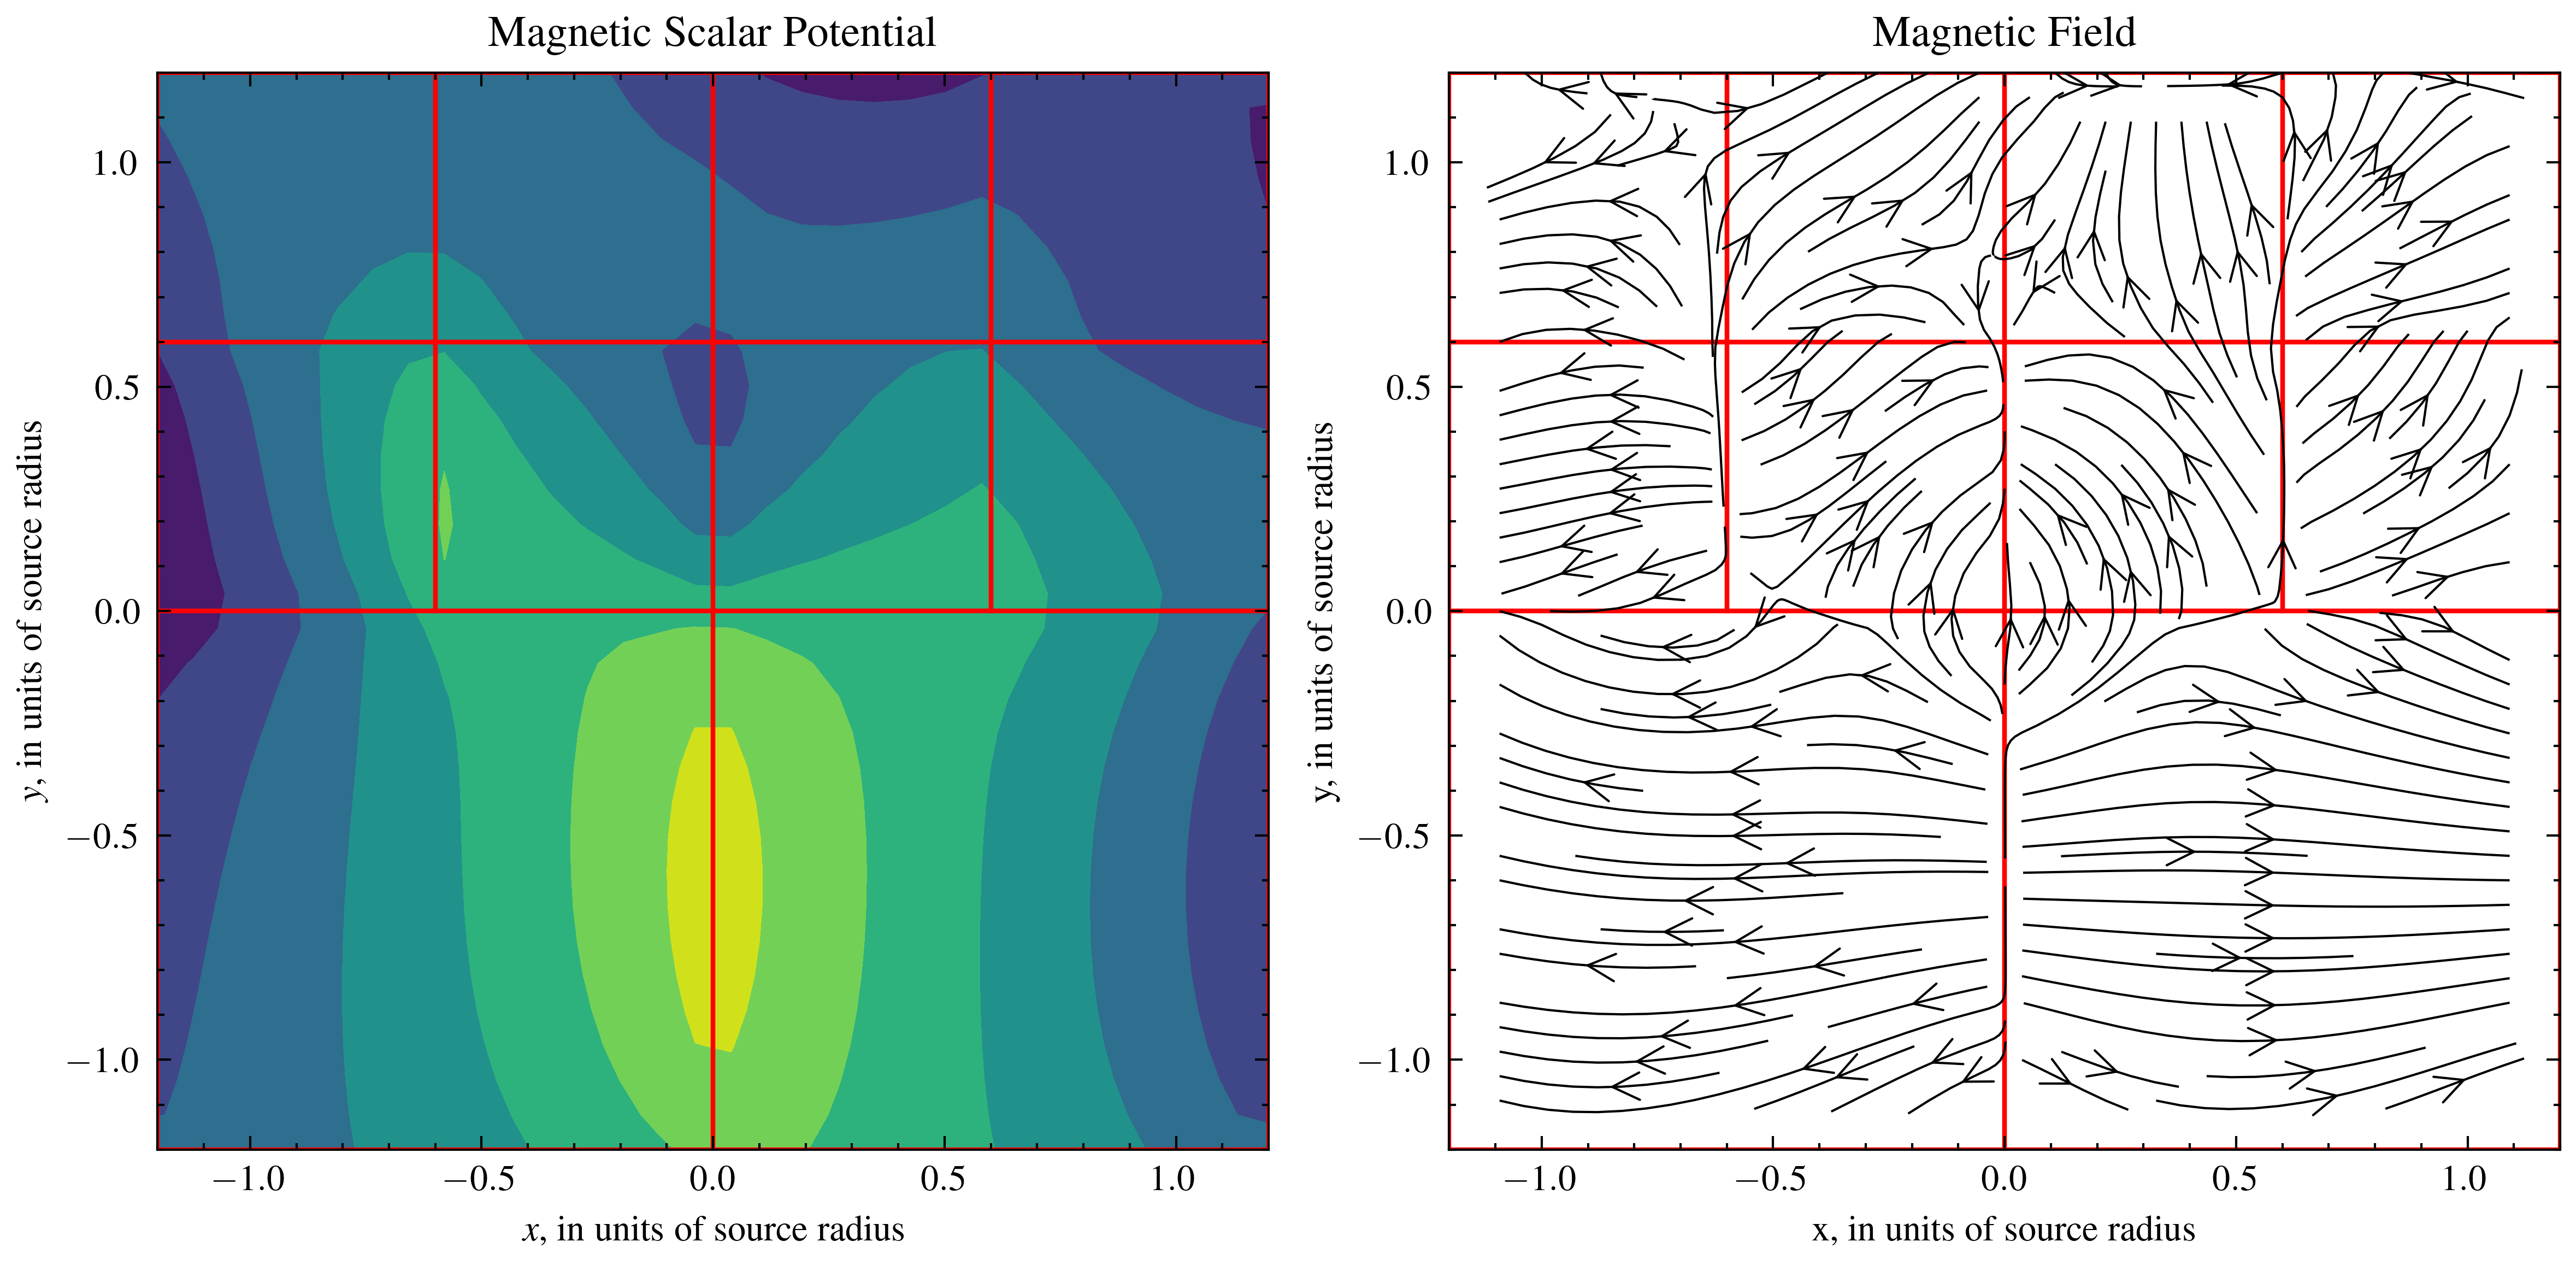

In [2]:
source_cfg = {
    "shape": "prism",
    "n_samples": 1,
    "n_sources": 10,
    "lim": 1.2,
    "res": 32,
    "dim": 2,
    "min_size": 0.12,
    "max_size": 0.48,
    "target_source": True,
    "line": False,
    "quadtree": False,
    "eps": 0,
    "seed": 0,
}
# train = configure(**source_cfg)
train = read_db("eval_large_m_qt_42_10_10.h5")
idx = 0
plots(train, loc=False, edge=True, idx=idx)

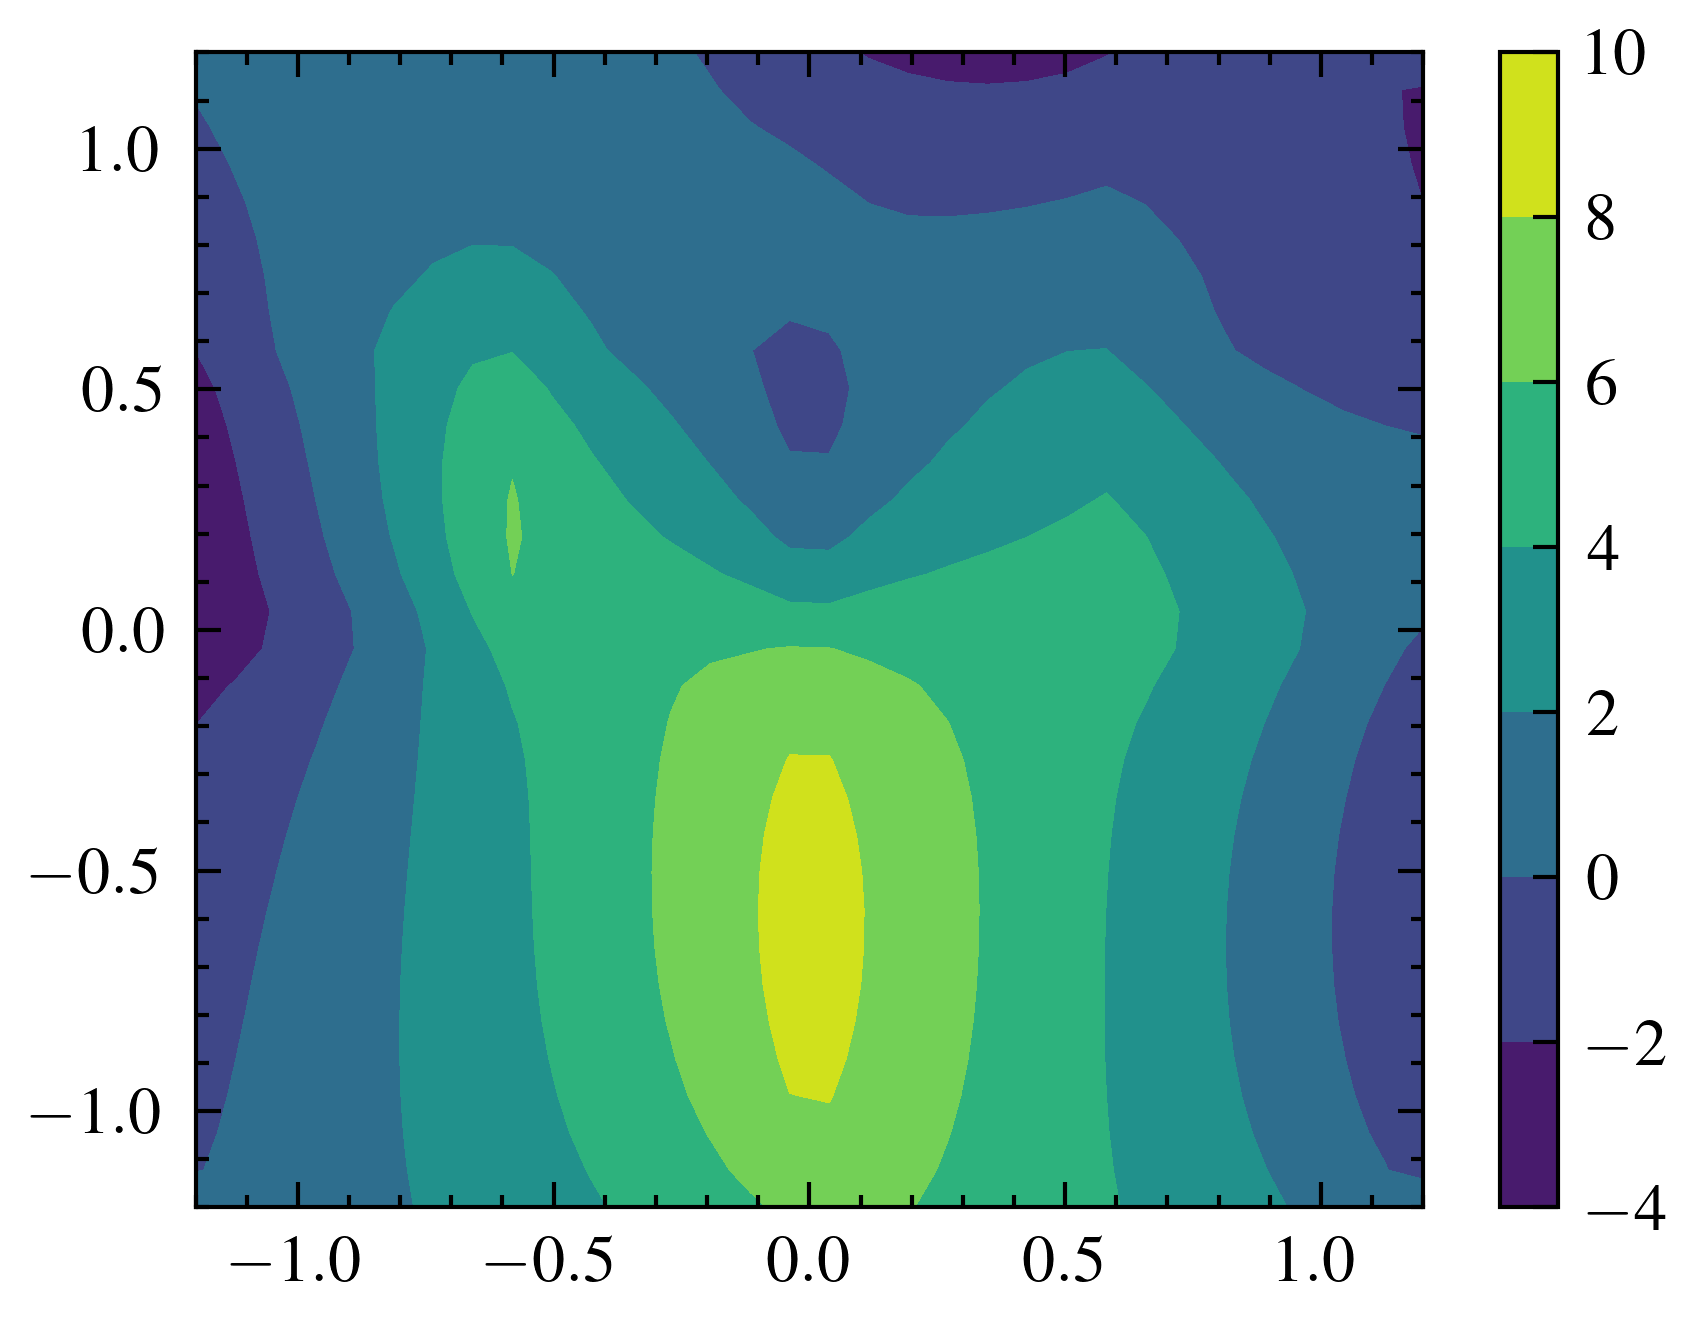

In [3]:
x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
t_msp = train["msp_grid"][idx].reshape((source_cfg["res"], source_cfg["res"]))
plt.contourf(x_grid, y_grid, t_msp)
plt.colorbar()

## Code from FMM2D
https://github.com/flatironinstitute/fmm2d/blob/main/src/laplace/rfmm2d.f#L144
- 2D dipole vector is represented in complex form `dx + i*dy`
- Can then be more easily treated as directional derivatives of monopole (source) potentials
- negative sign in `ztmp` is conventional; **TODO** Check how FMM is using this in Green's function

```
do i = 1,ns
    do j = 1,nd
        ztmp = -(dipvec(j,1,i)+eye*dipvec(j,2,i))
        dipstr1(j,i) = dipstr(j,i)*ztmp
    enddo
enddo
```


Potential: 0.1692356964441075


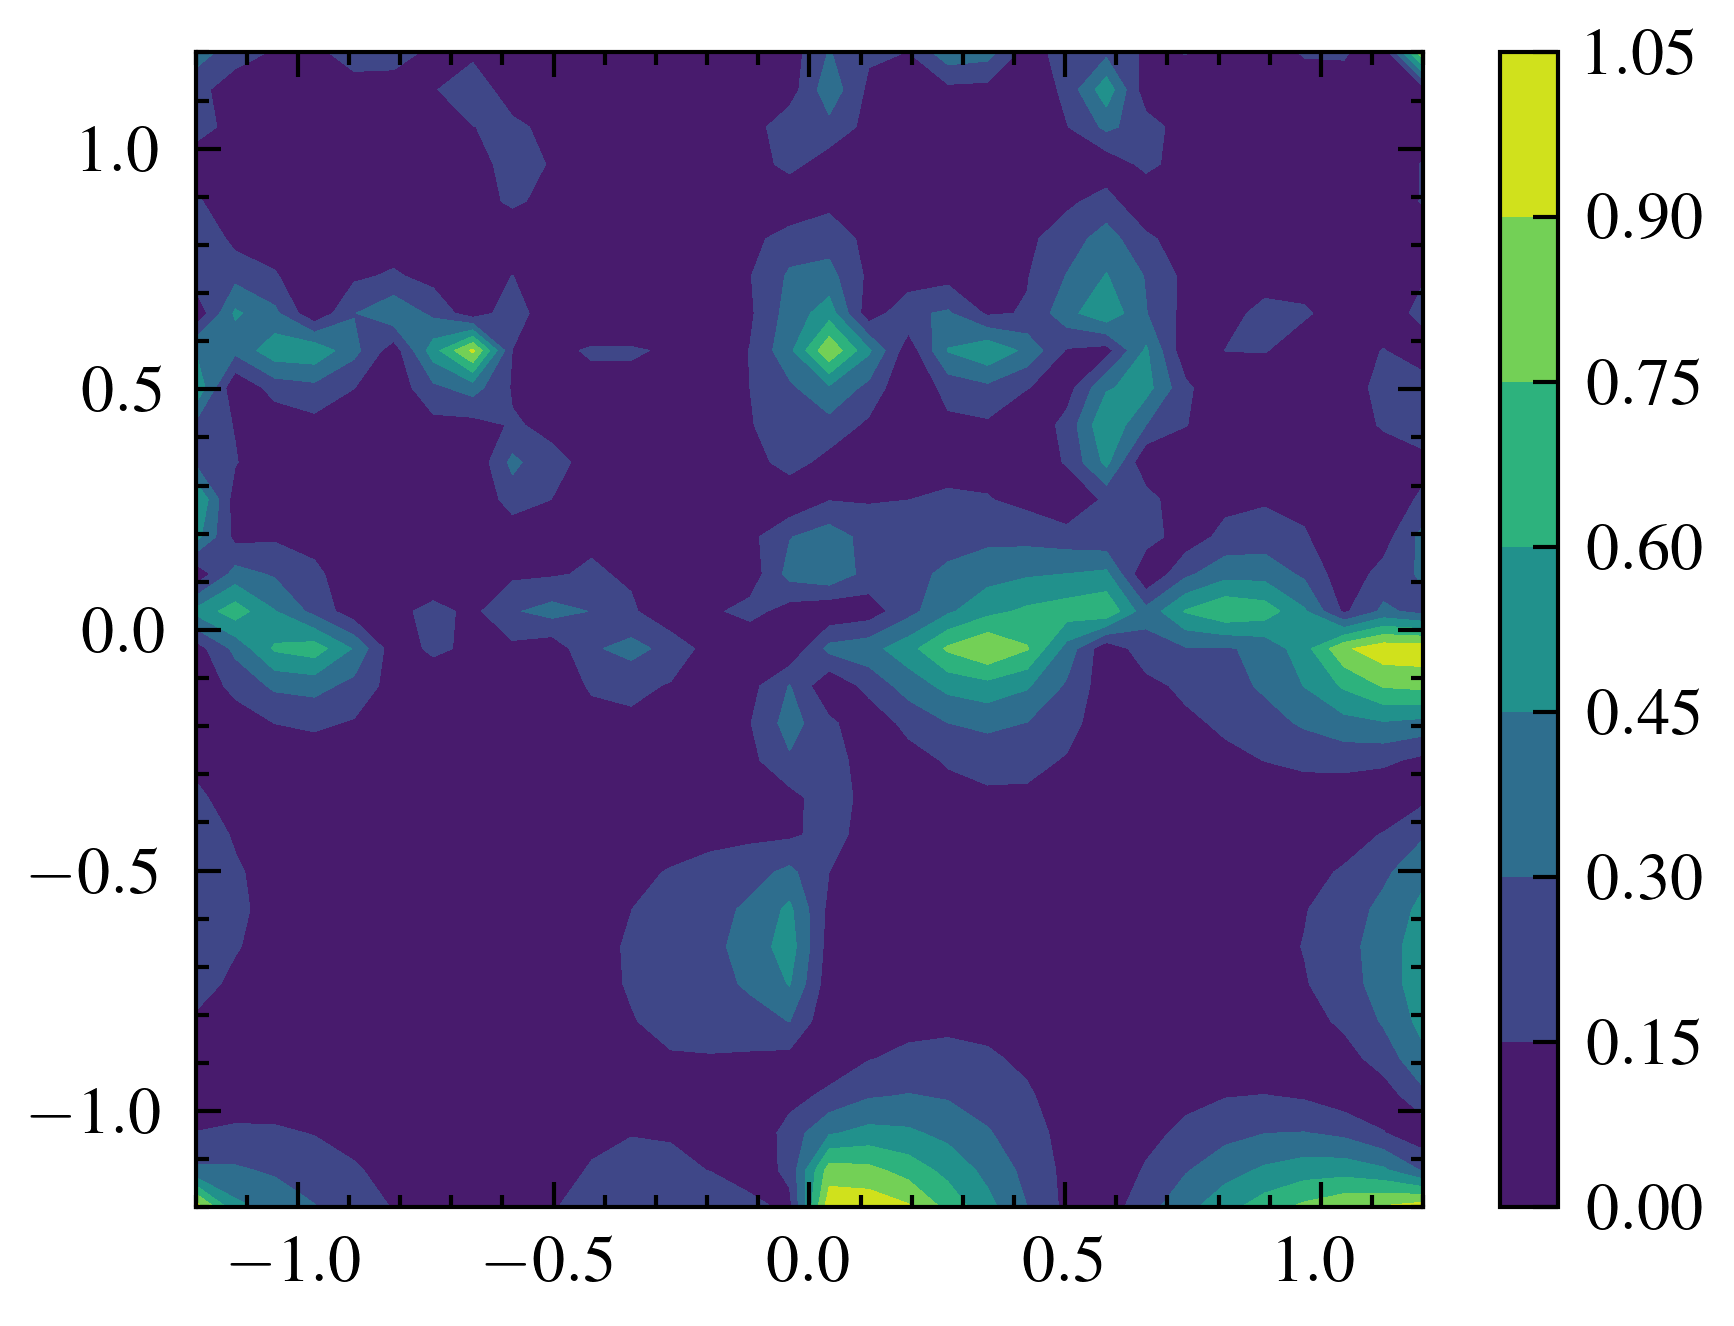

In [ ]:
sim = train.copy()
sim['msp_grid'], _, _ = potential2D(sim['sources'], sim['shape'], sim['grid'], prism_mt=False)

### Potential
if source_cfg["line"]:
    plt.plot(sim['grid'][:, 0], np.abs(sim["msp_grid"][0]))
    plt.plot(sim['grid'][:, 0], np.abs(train["msp_grid"][0]), color='red', linestyle='--')
    plt.plot(sim['grid'][:, 0], np.abs(train["msp_grid"][0] - sim["msp_grid"][0]), color='green', linestyle=':')
    plt.yscale("log")
    plt.legend(["Prism3D", "Dipole", "Error"])
else:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    sim_msp = sim["msp_grid"][idx].reshape((source_cfg["res"], source_cfg["res"]))
    t_msp = train["msp_grid"][idx].reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid, y_grid, np.clip(np.abs((sim_msp - t_msp)) / np.abs(t_msp), 1e-8, 10))
    # arr = np.clip(np.abs((sim_msp - t_msp)) / np.abs(t_msp), 1e-8, 10)
    # cf = plt.contourf(x_grid, y_grid, arr, norm=LogNorm(vmin=1e-8, vmax=10))
    # plt.colorbar(cf)
    plt.contourf(x_grid, y_grid, np.clip(np.abs(sim_msp - t_msp), 0, 1))
    plt.colorbar()

print("Potential:", np.nanmean(np.abs(sim_msp - t_msp)))

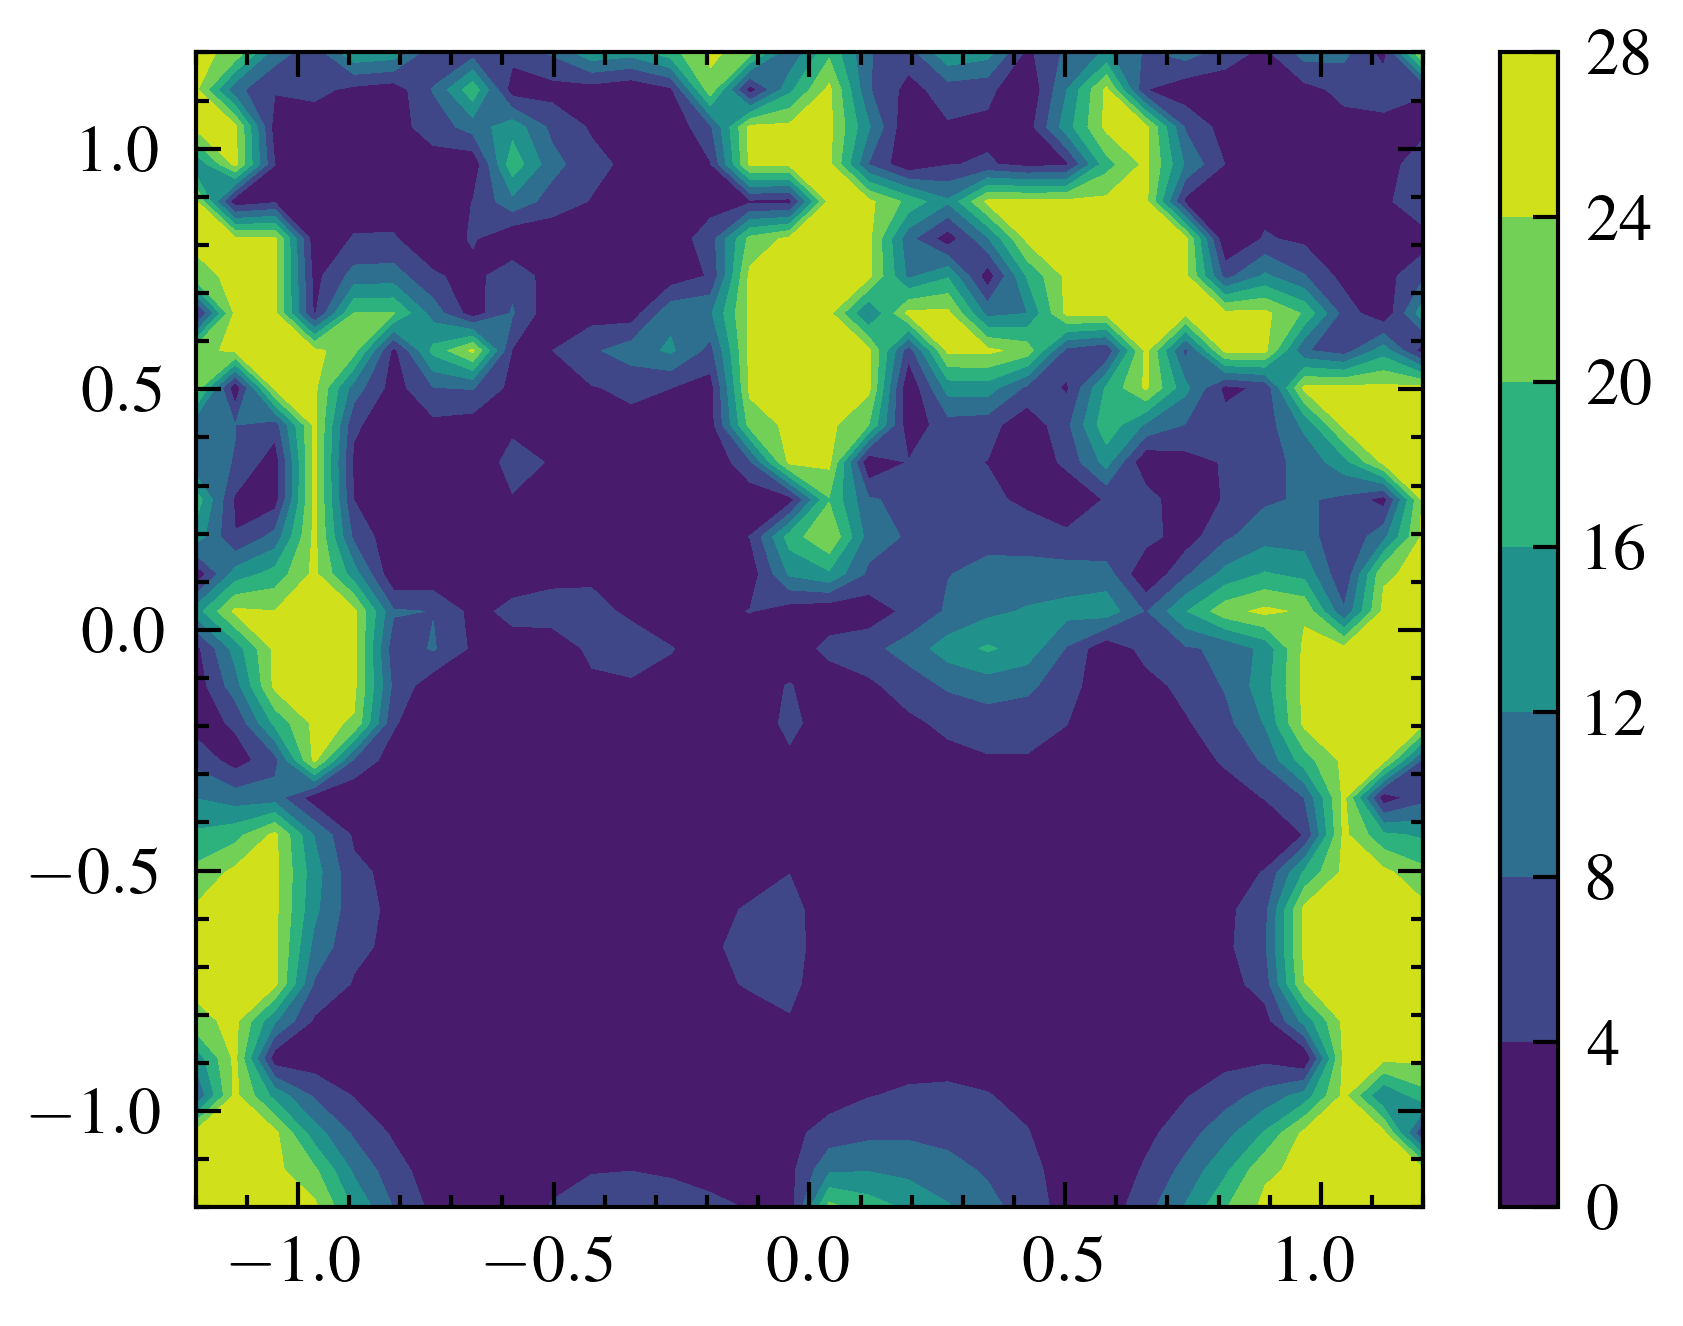

In [7]:
# Error
err = (np.abs(sim_msp - t_msp) / np.abs(t_msp)) * 100
plt.contourf(x_grid, y_grid, np.clip(err, 0, 25))
plt.colorbar()

(array([265., 215.,  97.,  70.,  50.,  30.,  33.,  23.,  12.,  16.,  10.,
         14.,  14.,  16.,  11.,   6.,   5.,   6.,   8.,   7.,   2.,   1.,
          8.,   3.,   1.,   5.,   2.,   5.,   2.,   1.,   2.,   3.,   4.,
          1.,   1.,   3.,   1.,   3.,   3.,   2.,   1.,   1.,   4.,   1.,
          2.,   6.,   1.,   0.,   0.,   4.]),
 array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
         22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
         44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
         66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
         88.,  90.,  92.,  94.,  96.,  98., 100.]),
 <BarContainer object of 50 artists>)

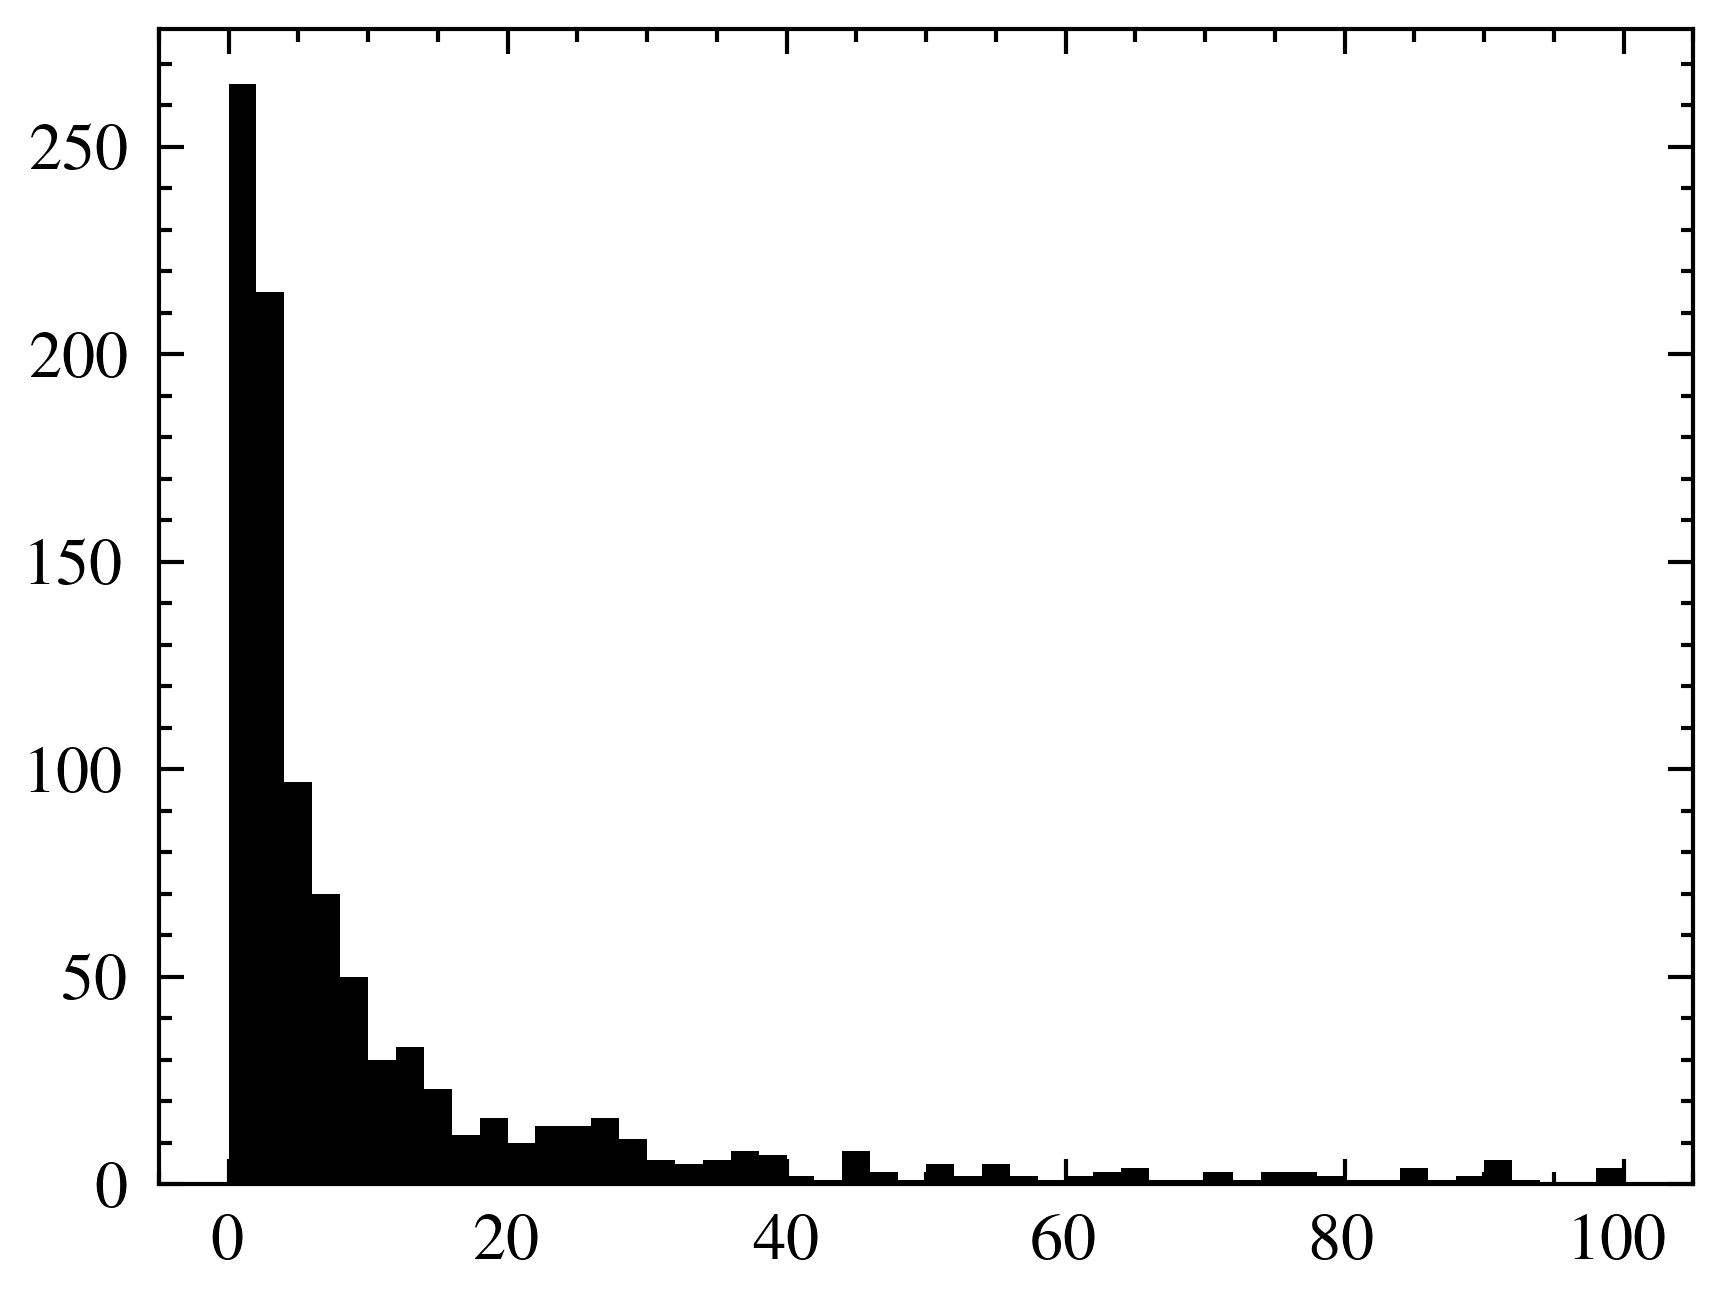

In [8]:
plt.hist(err.flatten(), bins=50, range=(0, 100))

## Directly from FMM2D

Field(y): 1.2668035544950613


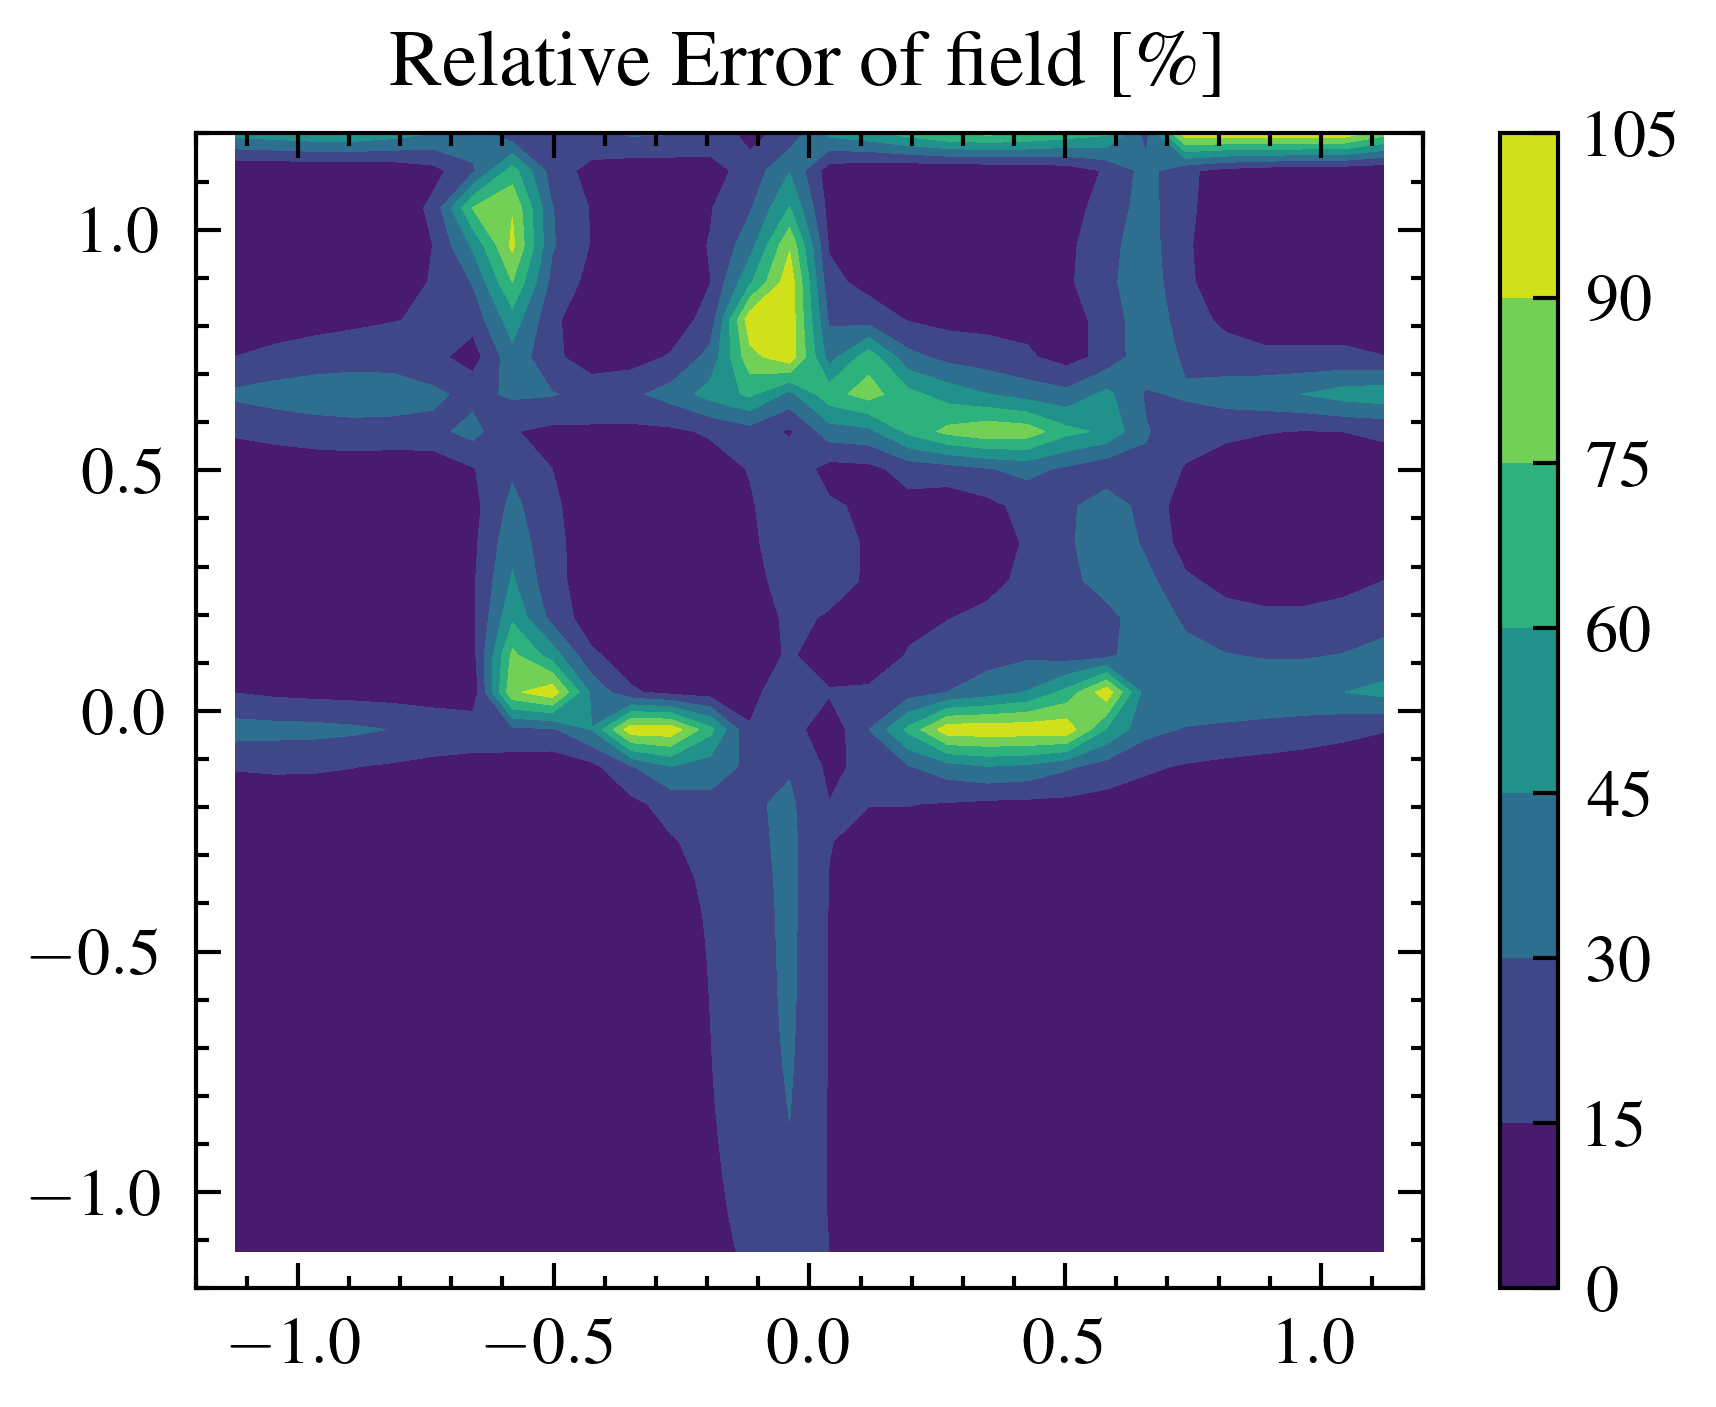

In [ ]:
_, sim['field_grid_direct'], _ = potential2D(sim['sources'], sim['shape'], sim['grid'], prism_mt=True)

### Field in x-direction
if source_cfg["line"]:
    plt.plot(sim['grid'][:, 0], np.abs(sim["field_grid_direct"][0, ..., 0]))
    plt.plot(sim['grid'][:, 0], np.abs(train["field_grid"][0, ..., 0]), color='red', linestyle='--')
    plt.plot(sim['grid'][:, 0], np.abs(train["field_grid"][0] - sim["field_grid_direct"][0]), color='green', linestyle=':')
    plt.yscale("log")
    plt.legend(["Prism3D", "Dipole", "Error"])
else:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    sim_f = sim["field_grid_direct"][0, ...]
    t_f = train["field_grid"][0, ..., :2]
    diff = np.linalg.norm(np.abs(sim_f - t_f), axis=-1).reshape((source_cfg["res"], source_cfg["res"]))
    norm_f = np.linalg.norm(t_f, axis=-1).reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid, y_grid, np.clip(sim_f[...,1], -5, 5))
    # plt.contourf(x_grid, y_grid, np.clip(t_f[...,1], -1, 1))
    plt.contourf(x_grid, y_grid, np.clip((diff / norm_f) * 100, 0, 100))
    plt.title("Relative Error of field [\%]")
    # plt.contourf(x_grid, y_grid, np.clip(sim_f[...,1] / t_f[...,1], 0, 3))
    plt.colorbar()

    print("Field(y):", np.nanmean(np.abs(sim_f[...,1] / t_f[...,1])))

## Equivalent for MagTense
2D magnetiziation in $xy$-plane and prism is elongated in $z$-direction.

Convert magnetic moment to magnetization: $M = m / (2 * a * 2 * b)$

1.0000000625970107


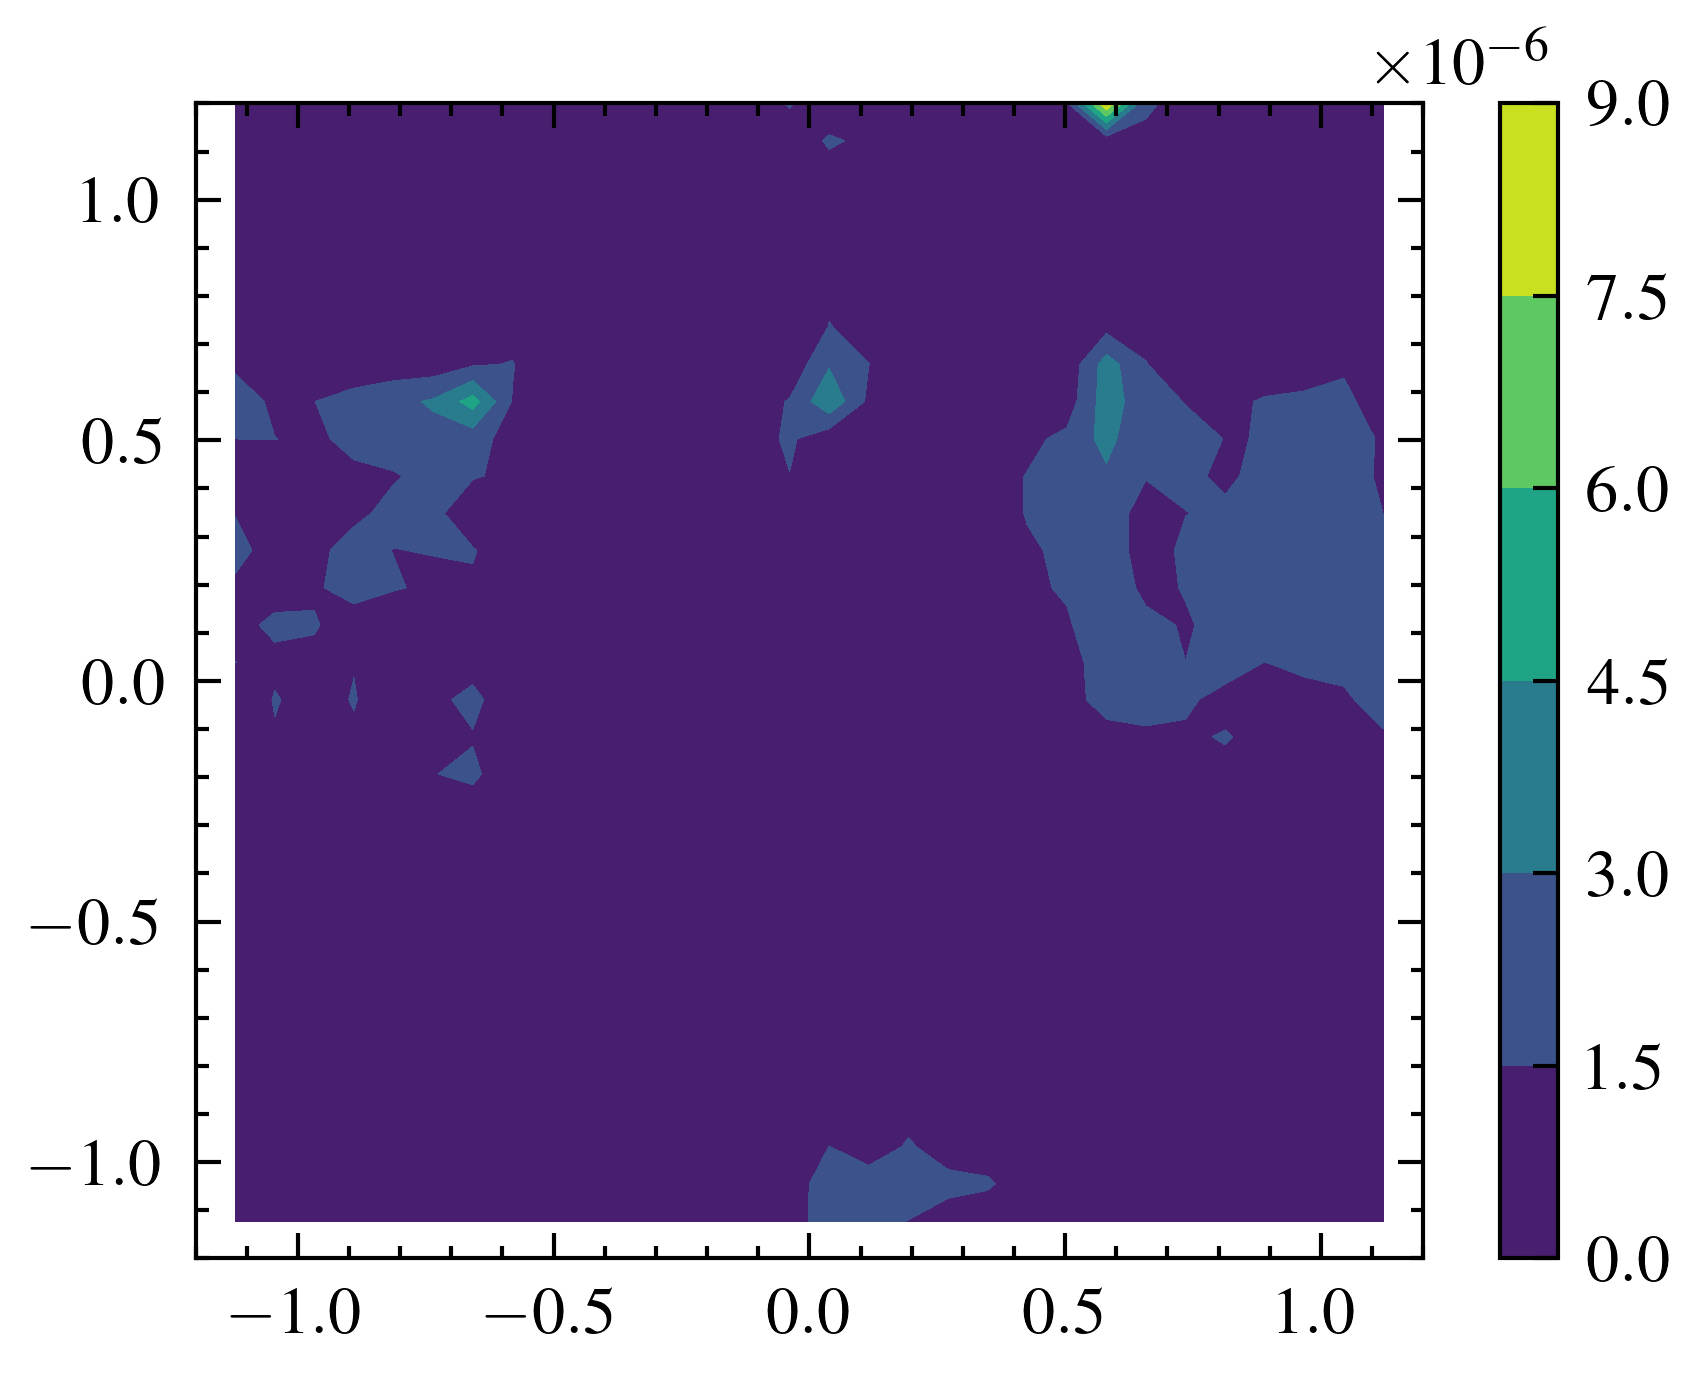

In [10]:
mt_sim, _ = field_mt(train['sources'], train['grid'], "prism")

if source_cfg["line"]:
    plt.plot(train['grid'][:, 0], train["field_grid"][idx, ..., 0])
    plt.plot(train['grid'][:, 0], mt_sim[idx, ..., 0], color='red', linestyle='--')
    # plt.plot(train['grid'][:, 0], train["field_grid"][idx, ..., 0], color='red', linestyle='--')
    plt.plot(train['grid'][:, 0], mt_sim[idx, ..., 0] / train["field_grid"][idx, ..., 0], color='green', linestyle=':')
    # plt.yscale("log")
    # plt.xlim(5,15)
    plt.ylim(-2, 2)
    plt.legend(["Analytical", "MagTense", "Error"])
    print(np.nanmean(np.abs(mt_sim[idx, :, 0] / train["field_grid"][idx, :, 0])))

else:
    x_grid_pr = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid_pr = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    mt_f_grid_x = np.array(mt_sim[idx, ..., 0].reshape((source_cfg["res"], source_cfg["res"])))
    t_f = train["field_grid"][idx, ..., 0].reshape((source_cfg["res"], source_cfg["res"]))
    plt.contourf(x_grid_pr, y_grid_pr, np.clip(np.abs(mt_f_grid_x - t_f), 0, 1))
    plt.colorbar()
    print(np.nanmean(np.abs(mt_f_grid_x / t_f)))

In [ ]:
for eps in [0, 1e-3, 1e-5, 1e-7, 1e-9]:
    # print("Source 1 on all other locations")
    # source = train['sources'][0:1, 0:1]
    # loc = train['r'][0][1:]
    # mt_sim, _ = field_mt(source, loc + eps, train['shape'])
    # # print(np.mean(np.abs(mt_sim[0, ..., :2])))
    # _, fmm_field, _ = potential2D(source, train['shape'], loc + eps)
    # # print(np.mean(np.abs(mt_sim[..., :2] - fmm_field)[0]))
    # rel_err = np.abs((mt_sim[..., :2] - fmm_field) / mt_sim[..., :2]) * 100
    # print(f"Eps: {eps:.1e}, Mean Error: {np.mean(rel_err):.2f} [%], Median Error: {np.median(rel_err):.2f} [%]")

    # print("Other sources on source 1")
    # source = train['sources'][0:1, 1:]
    # loc = train['r'][0][0:1]
    # mt_sim, _ = field_mt(source, loc + eps, train['shape'])
    # # print(np.mean(np.abs(mt_sim[0, ..., :2])))
    # _, fmm_field, _ = potential2D(source, train['shape'], loc + eps)
    # # print(np.mean(np.abs(mt_sim[..., :2] - fmm_field)[0]))
    # rel_err = np.abs((mt_sim[..., :2] - fmm_field) / mt_sim[..., :2]) * 100
    # print(f"Eps: {eps:.1e}, Mean Error: {np.mean(rel_err):.2f} [%], Median Error: {np.median(rel_err):.2f} [%]")

    # print("Source 1 on all locations")
    source = train['sources'][0:1, 0:1]
    loc = train['r'][0]
    mt_sim_s, _ = field_mt(source, loc + eps, train['shape'])
    # print(np.mean(np.abs(mt_sim[0, ..., :2])))
    _, fmm_field, _ = potential2D(source, train['shape'], loc + eps)
    # print(np.mean(np.abs(mt_sim[..., :2] - fmm_field)[0]))
    rel_err = np.abs((mt_sim_s[..., :2] - fmm_field) / mt_sim_s[..., :2]) * 100
    print(f"Eps: {eps:.1e}, Mean Error: {np.mean(rel_err):.2f} [%], Median Error: {np.median(rel_err):.2f} [%]")
    print(fmm_field[0, 0, :2])
    print(mt_sim_s[0, 0, :2])
    print("\n")

Eps: 0.0e+00, Mean Error: 9.29 [%], Median Error: 5.17 [%]
[-3.24945998 -0.59239304]
[-3.24203955 -0.59104027]


Eps: 1.0e-03, Mean Error: 9.41 [%], Median Error: 5.16 [%]
[-3.25030276 -0.57450311]
[-3.2420385  -0.59103453]


Eps: 1.0e-05, Mean Error: 10164.93 [%], Median Error: 6.19 [%]
[ 481.3439815  1111.54757297]
[-3.24203955 -0.59104027]


Eps: 1.0e-07, Mean Error: 41831117.51 [%], Median Error: 6.19 [%]
[  787608.07475877 -4801188.98301804]
[-3.24203955 -0.59104027]


Eps: 1.0e-09, Mean Error: 9.29 [%], Median Error: 5.17 [%]
[-3.24945998 -0.59239304]
[-3.24203955 -0.59104027]




# FC-ILR field plots

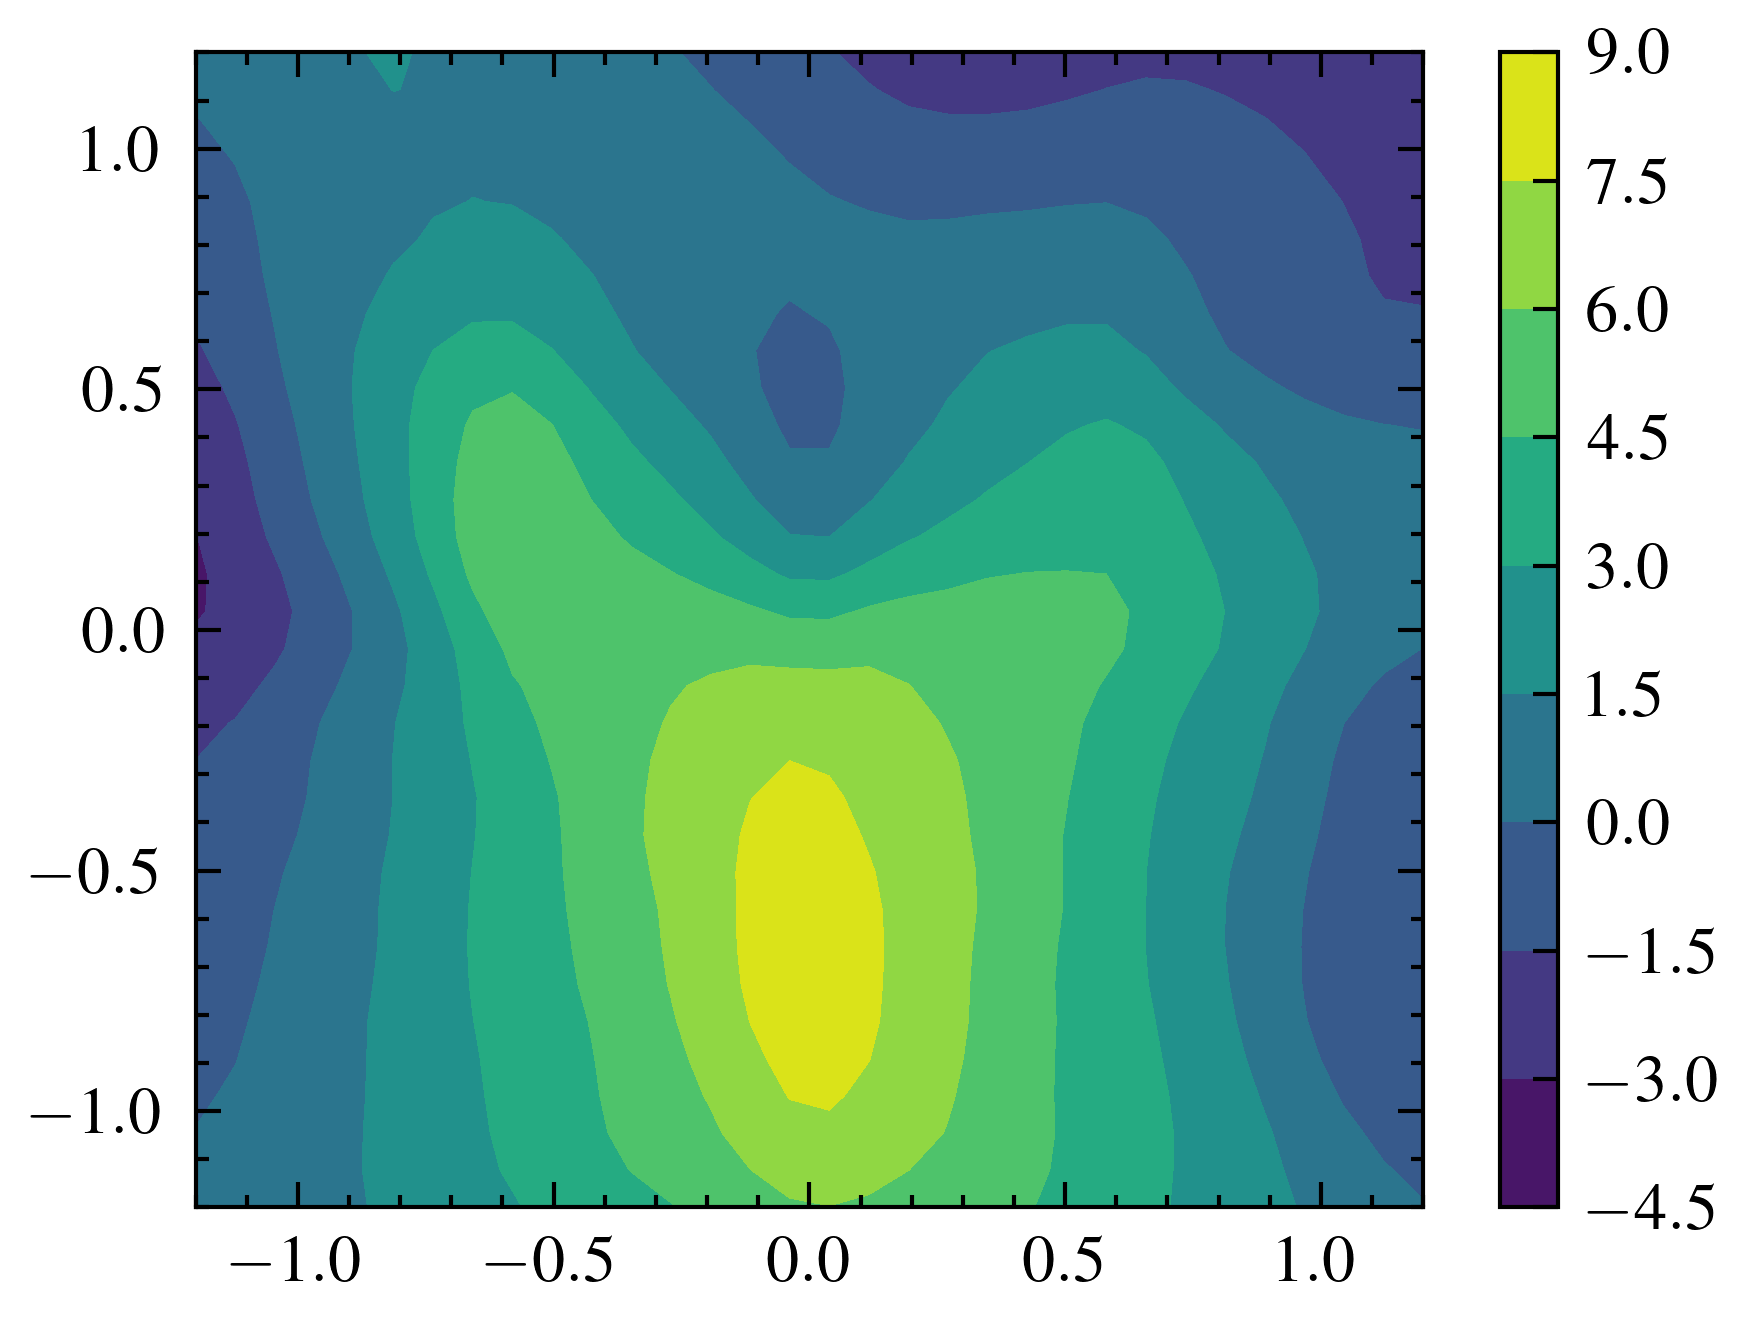

In [13]:
model_cfg = HyperLayer(
    width=400,
    depth=3,
    hwidth=2,
    hdepth=3,
    seed=42,
)

model_folder = Path().resolve() / '..' / 'models'
model_path = f"{model_folder}/fc_ilr_400_200k_res32_large_m.eqx"
model = eqx.tree_deserialise_leaves(model_path, model_cfg)

sim['field_grid_model'] = jax.vmap(model.field, in_axes=(0, None))(
    train['sources'][idx:idx+1], train['grid']
)[0]
sim['msp_grid_model'] = jax.vmap(model, in_axes=(0, None))(
    train['sources'][idx:idx+1], train['grid']
)[0]
if not source_cfg["line"]:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    sim_f = sim["msp_grid_model"].reshape((source_cfg["res"], source_cfg["res"]))
    plt.contourf(x_grid, y_grid, sim_f)
    # plt.contourf(x_grid, y_grid, np.clip((diff / norm_f) * 100, 0, 100))
    # plt.title("Relative Error of field [\%]")
    plt.colorbar()

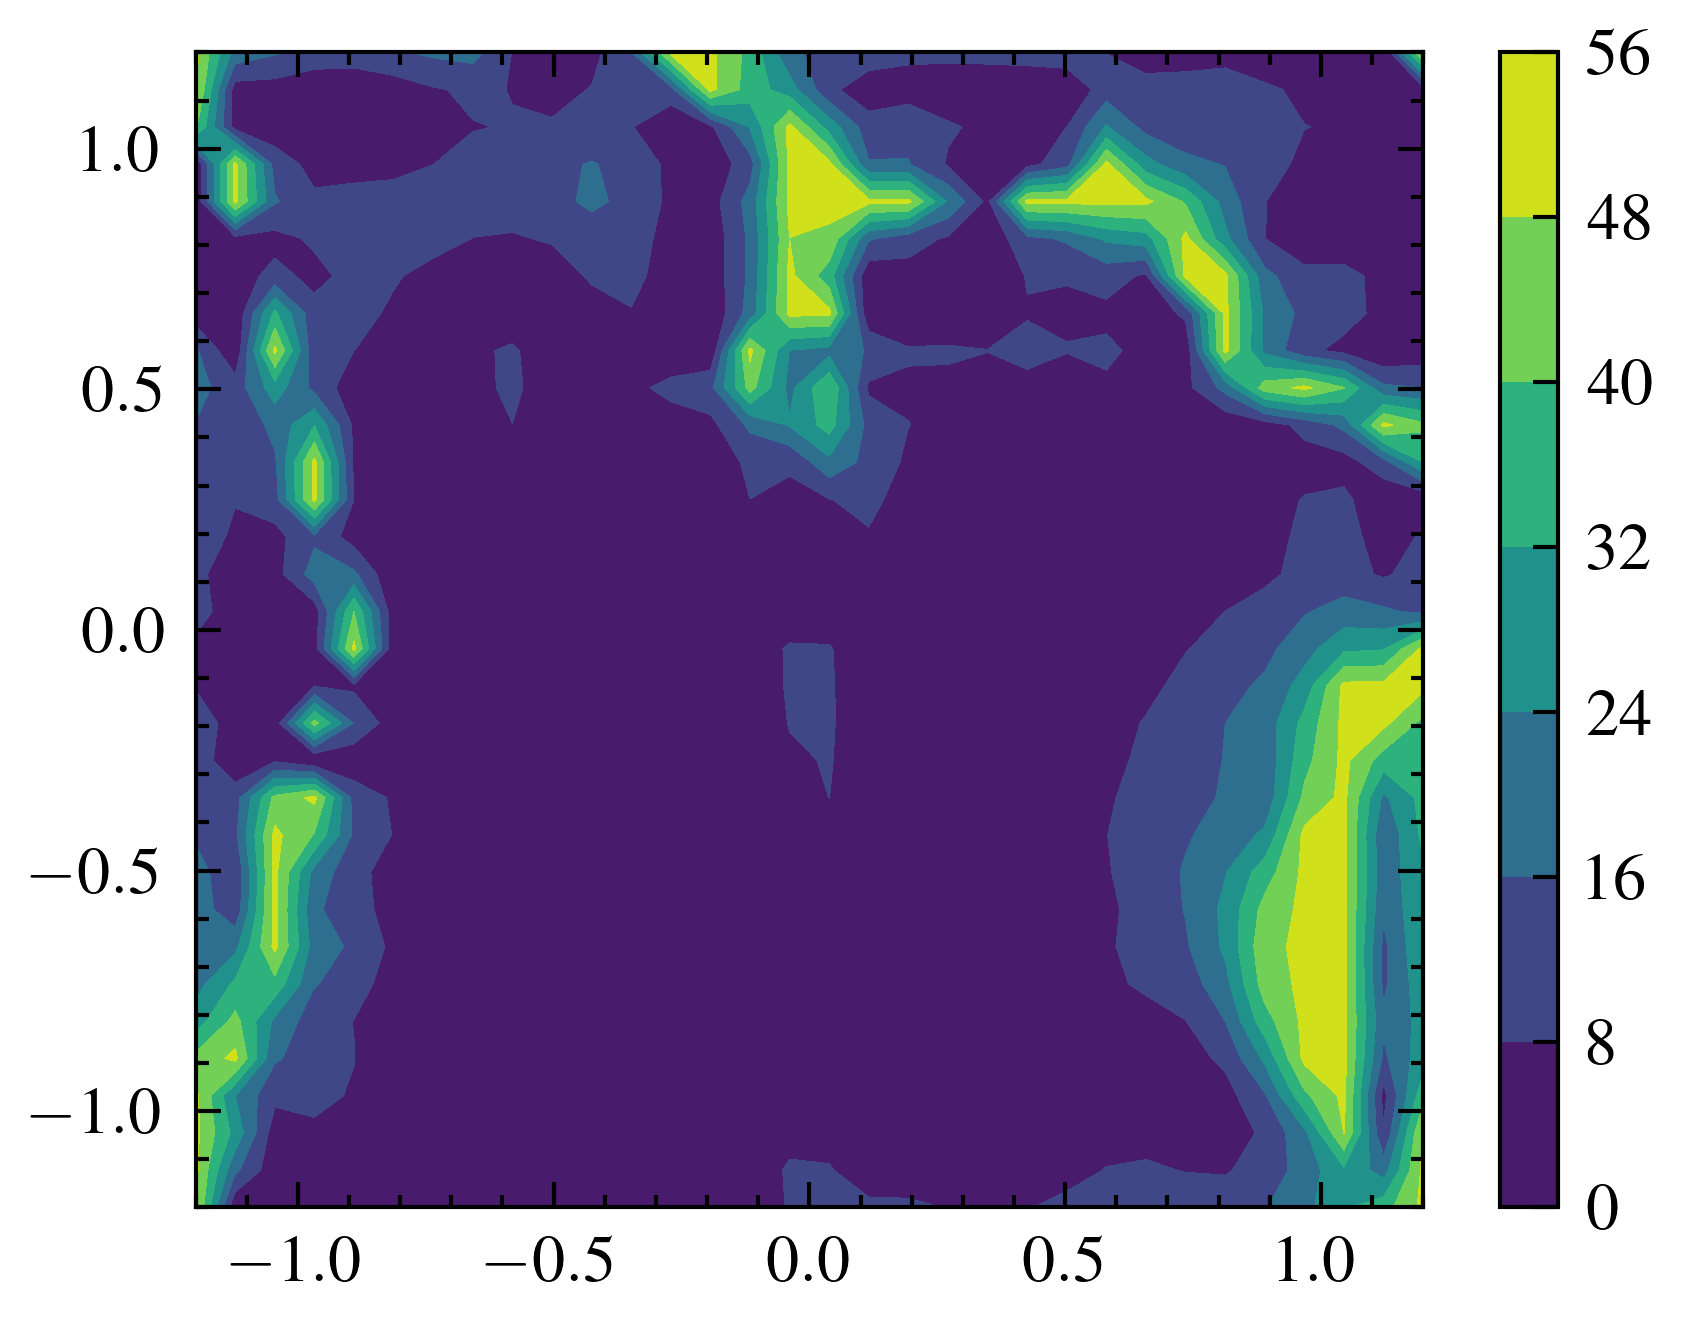

In [14]:
# Error FCILR
err_fcilr = (np.abs(sim_f - t_msp) / np.abs(t_msp)) * 100
plt.contourf(x_grid, y_grid, np.clip(err_fcilr, 0, 50))
plt.colorbar()

(array([216., 178., 132.,  91.,  72.,  53.,  40.,  32.,  30.,  18.,  14.,
          8.,   9.,   6.,   6.,   8.,   5.,   4.,  10.,   5.,   4.,   7.,
          2.,   2.,   2.,   3.,   2.,   2.,   4.,   4.,   1.,   0.,   3.,
          2.,   0.,   0.,   1.,   0.,   2.,   0.,   0.,   0.,   2.,   0.,
          0.,   3.,   0.,   3.,   4.,   2.]),
 array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
         22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
         44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
         66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
         88.,  90.,  92.,  94.,  96.,  98., 100.]),
 <BarContainer object of 50 artists>)

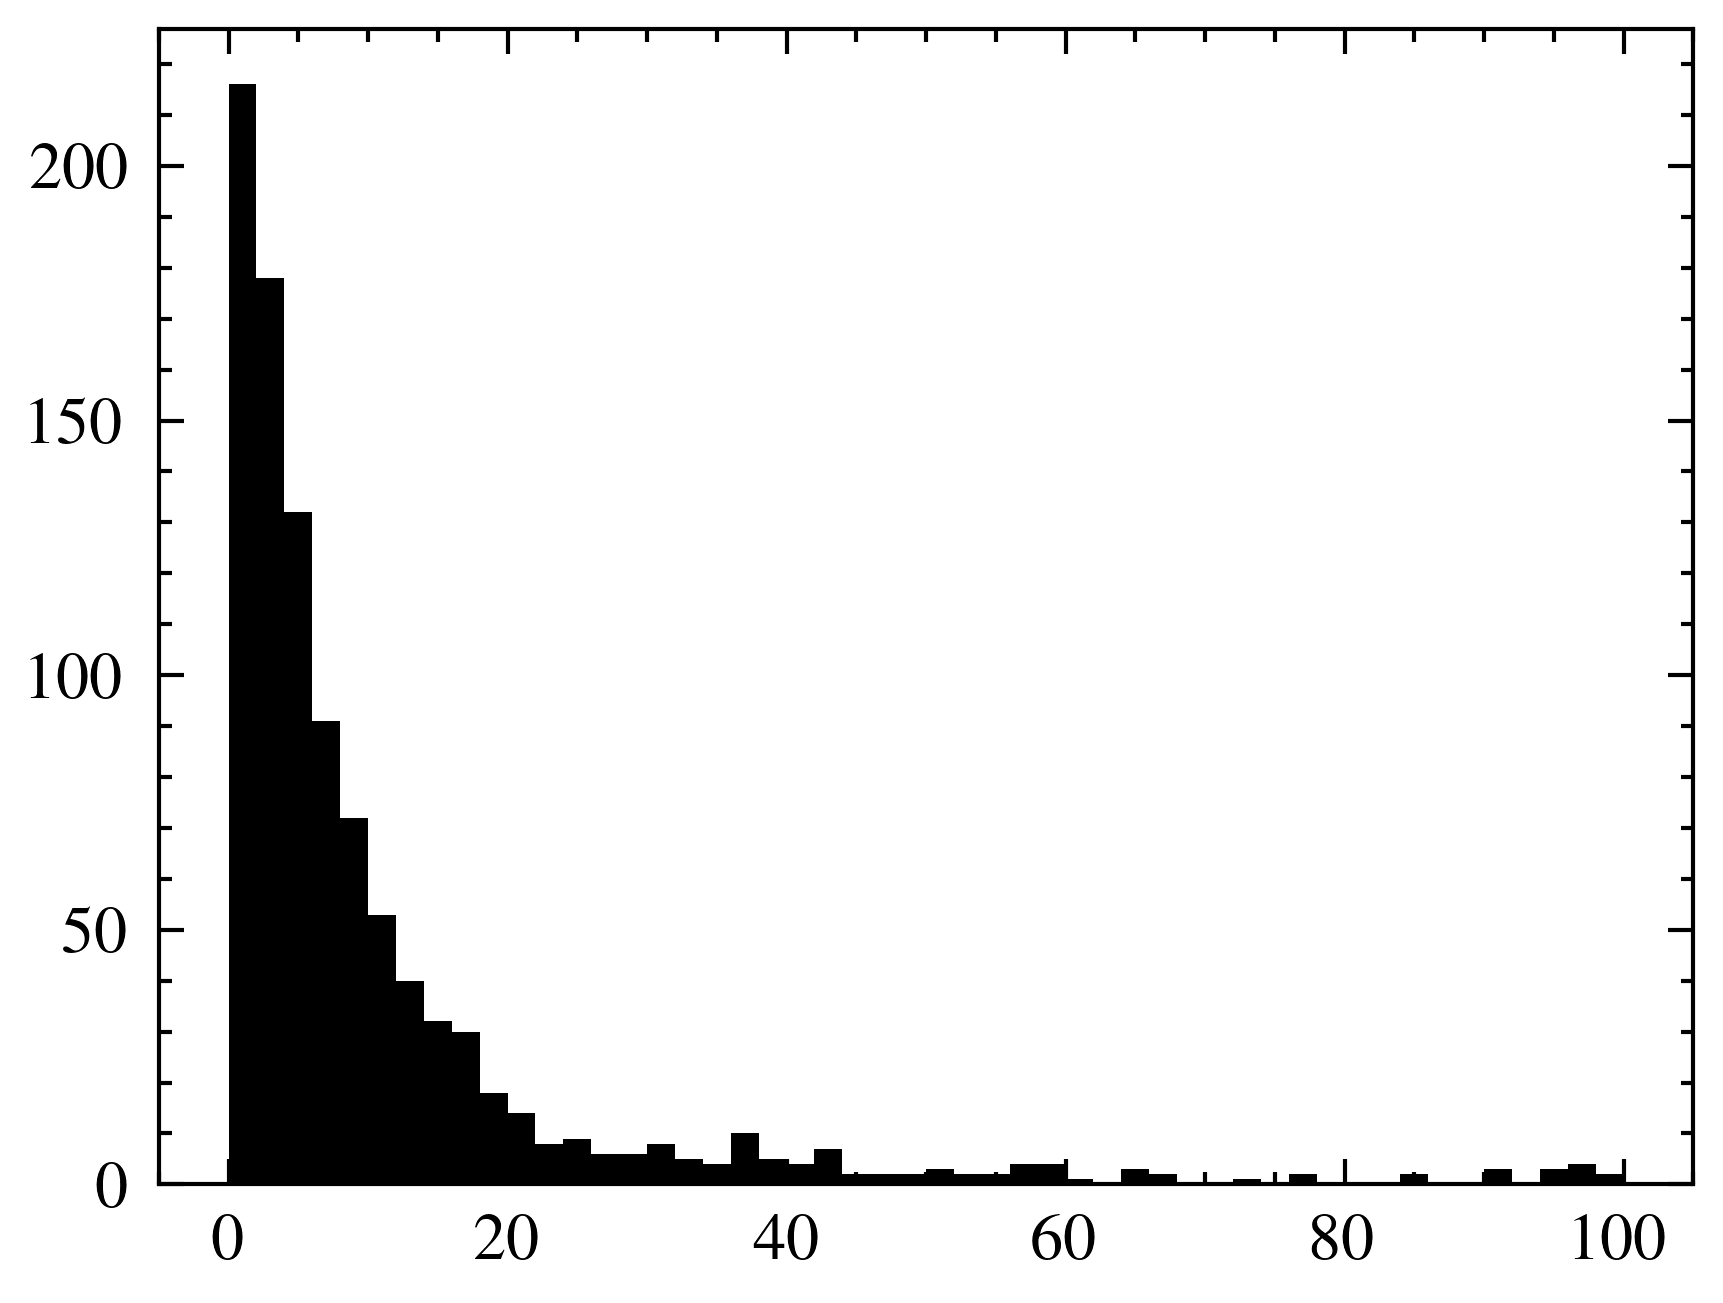

In [15]:
plt.hist(err_fcilr.flatten(), bins=50, range=(0, 100))